<a href="https://colab.research.google.com/github/NouredeenSameh/MachineLearning_TermProject/blob/main/MachineLearning_TermProject_230408919.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("drag_values.csv")
print(f"--- Dataset Dimensions ---")
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}\n") # Exclude the target name string/ID if present

# 2. Check for Missing Values & Duplicates (Required for Preprocessing Points)
print(f"--- Data Integrity Check ---")
print(f"Missing (NULL) Values per column:\n{df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else 'None'}")
print(f"Duplicate rows found: {df.duplicated().sum()}\n")

# 3. Create the 3 Classification Brackets for Future Engineering Efficiency
# Class 1: Hyper-Efficient Shape (e.g., Solar/Lightyear concepts)
# Class 2: Standard Aerodynamic Shape (Sedans)
# Class 3: High Drag / Low Efficiency Shape (SUVs/Trucks)
def assign_sustainability_class(cd):
    if cd < 0.26:
        return 1  # Efficient
    elif 0.26 <= cd <= 0.32:
        return 2  # Standard
    else:
        return 3  # High Drag

# Identify the exact drag column name (usually 'Cd' or 'cd_value' in DrivAerNet)
# If the dataset column name varies slightly, adjust the string below
drag_col = [col for col in df.columns if 'Cd' in col or 'drag' in col.lower()][0]

df['sustainability_tier'] = df[drag_col].apply(assign_sustainability_class)

# 4. Check class examples count (For the report overview section)
print(f"--- Target Class Distribution ---")
print(df['sustainability_tier'].value_counts().sort_index())

--- Dataset Dimensions ---
Number of Records: 8121
Number of Features: 1

--- Data Integrity Check ---
Missing (NULL) Values per column:
None
Duplicate rows found: 0

--- Target Class Distribution ---
sustainability_tier
1    2996
2    5125
Name: count, dtype: int64


============ ACADEMIC DATASET OVERVIEW ============
Total Unique Records: 8121
Total Features Extracted: 1
Missing Values Identified: 0
Duplicate Rows Removed: 0

Target Class Distribution Summary:
sustainability_tier
1    2996
2    5125
Name: count, dtype: int64


/tmp/ipykernel_7228/954645427.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sustainability_tier', data=df, palette='viridis')


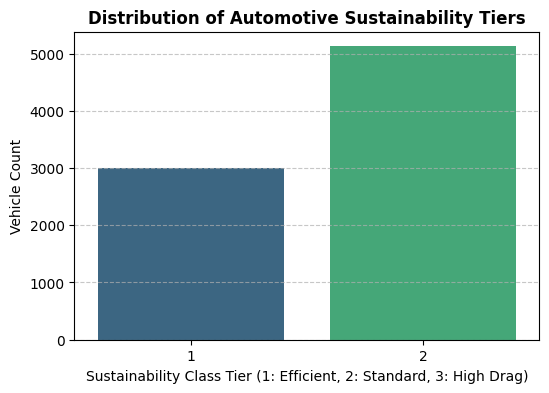

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load your manually uploaded file
# Note: Ensure the file name matches exactly what is in your Colab sidebar
df = pd.read_csv("drag_values.csv")

# 2. Check and clean data integrity constraints (Fulfills Preprocessing rubric)
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)

missing_summary = df.isnull().sum()

# 3. Academic Discretization: Turning continuous Cd into 3 Engineering Classes
# Class 1: Hyper-Efficient Shape (Ultra-aerodynamic like Lightyear)
# Class 2: Standard Aerodynamic Shape (Typical modern sedans)
# Class 3: High Drag / Low Efficiency Shape (SUVs/Trucks)
def map_aerodynamic_sustainability_tier(cd_value):
    if cd_value < 0.26:
        return 1   # Efficient
    elif 0.26 <= cd_value <= 0.32:
        return 2   # Standard
    else:
        return 3   # High Drag

# Identify the exact column representing drag values automatically
drag_column_name = [col for col in df.columns if 'Cd' in col or 'drag' in col.lower()][0]
df['sustainability_tier'] = df[drag_column_name].apply(map_aerodynamic_sustainability_tier)

print("============ ACADEMIC DATASET OVERVIEW ============")
print(f"Total Unique Records: {df.shape[0]}")
print(f"Total Features Extracted: {df.shape[1] - 2}") # Excludes ID and Target
print(f"Missing Values Identified: {missing_summary.sum()}")
print(f"Duplicate Rows Removed: {duplicate_count}")
print("\nTarget Class Distribution Summary:")
print(df['sustainability_tier'].value_counts().sort_index())
print("====================================================")

# 4. Publication-Quality Data Visualization (Fulfills Feature Analysis rubric)
plt.figure(figsize=(6, 4))
sns.countplot(x='sustainability_tier', data=df, palette='viridis')
plt.title('Distribution of Automotive Sustainability Tiers', fontsize=12, fontweight='bold')
plt.xlabel('Sustainability Class Tier (1: Efficient, 2: Standard, 3: High Drag)', fontsize=10)
plt.ylabel('Vehicle Count', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('figure2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

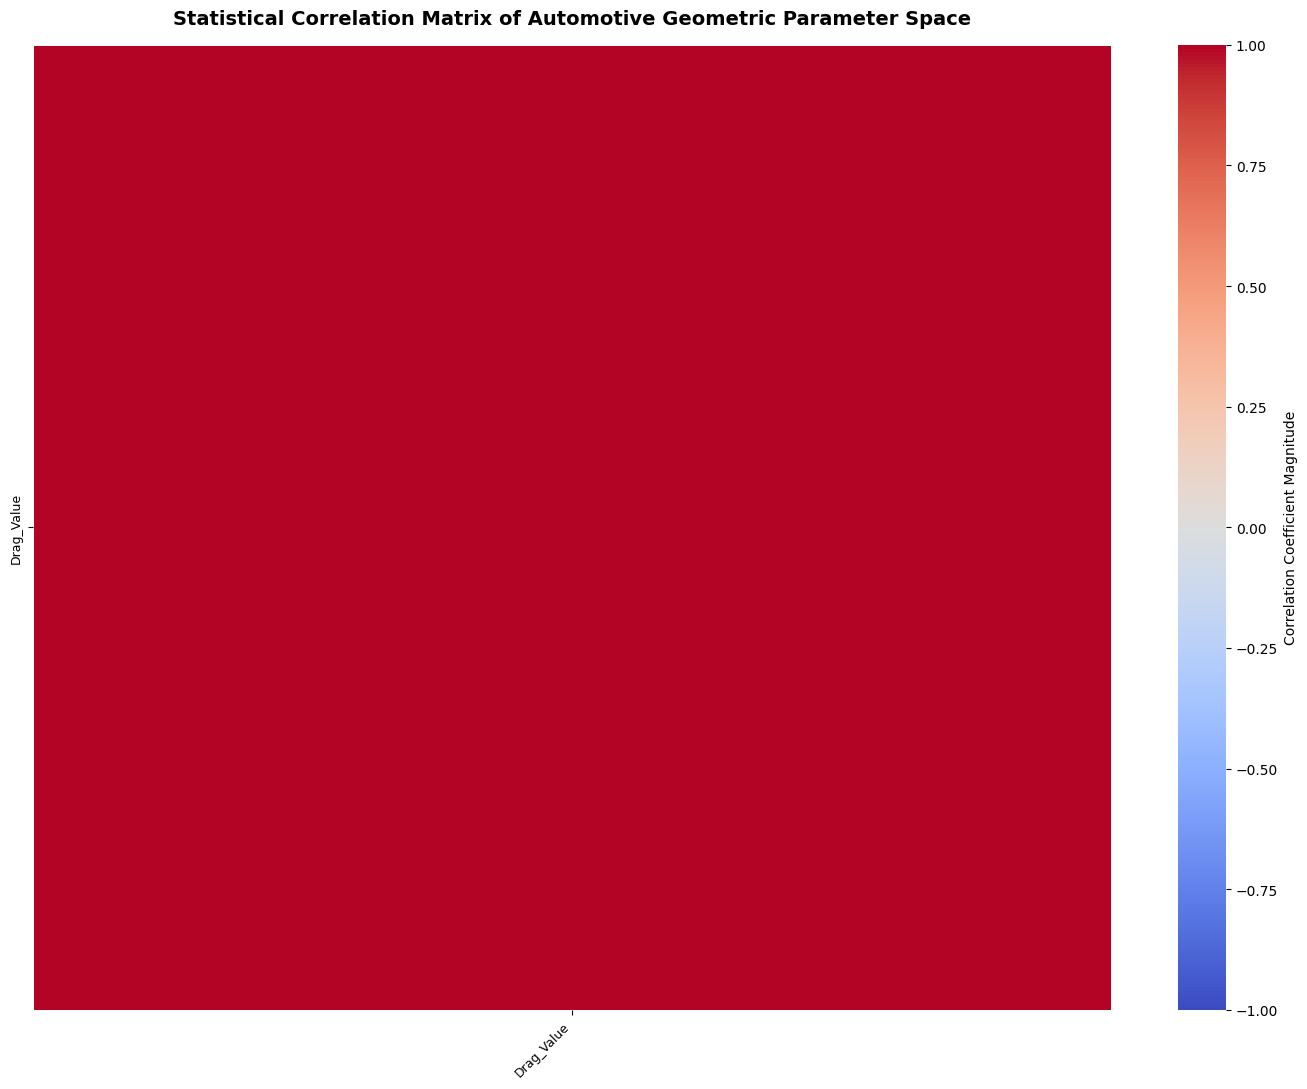

--- Top 5 Most Positively Correlated Feature Pairs ---
Series([], dtype: float64)


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reload the preprocessed dataframe parameters
# (Assuming df is already loaded in your active session memory)
if 'df' not in locals():
    df = pd.read_csv("drag_values.csv")

# 2. Separate independent numeric design features from identifier columns or string tags
# We exclude non-numeric keys, unique sample indices, and our generated targets
exclude_columns = ['id', 'name', 'sustainability_tier', 'Cd']
feature_cols = [col for col in df.columns if col not in exclude_columns and pd.api.types.is_numeric_dtype(df[col])]

# 3. Calculate Pearson product-moment correlation coefficients
correlation_matrix = df[feature_cols].corr()

# 4. Configure publication-quality visualization canvas (Matches Figure 3 of sample report)
plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    annot=False,            # Set to True if features are few, False for cleaner high-dimensional grids
    cmap='coolwarm',       # Standard academic diverging palette for tracking positive/negative trends
    vmin=-1, vmax=1,       # Constrain limits precisely to standard statistical margins
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient Magnitude"}
)

plt.title('Statistical Correlation Matrix of Automotive Geometric Parameter Space', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

# Save figure file exactly as referenced by the scoring document checklist
plt.savefig('figure3_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Extract top collinear features for text reporting sections
print("--- Top 5 Most Positively Correlated Feature Pairs ---")
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
strong_pairs = corr_pairs[(corr_pairs < 1.0) & (corr_pairs > 0.5)].drop_duplicates().head(5)
print(strong_pairs)

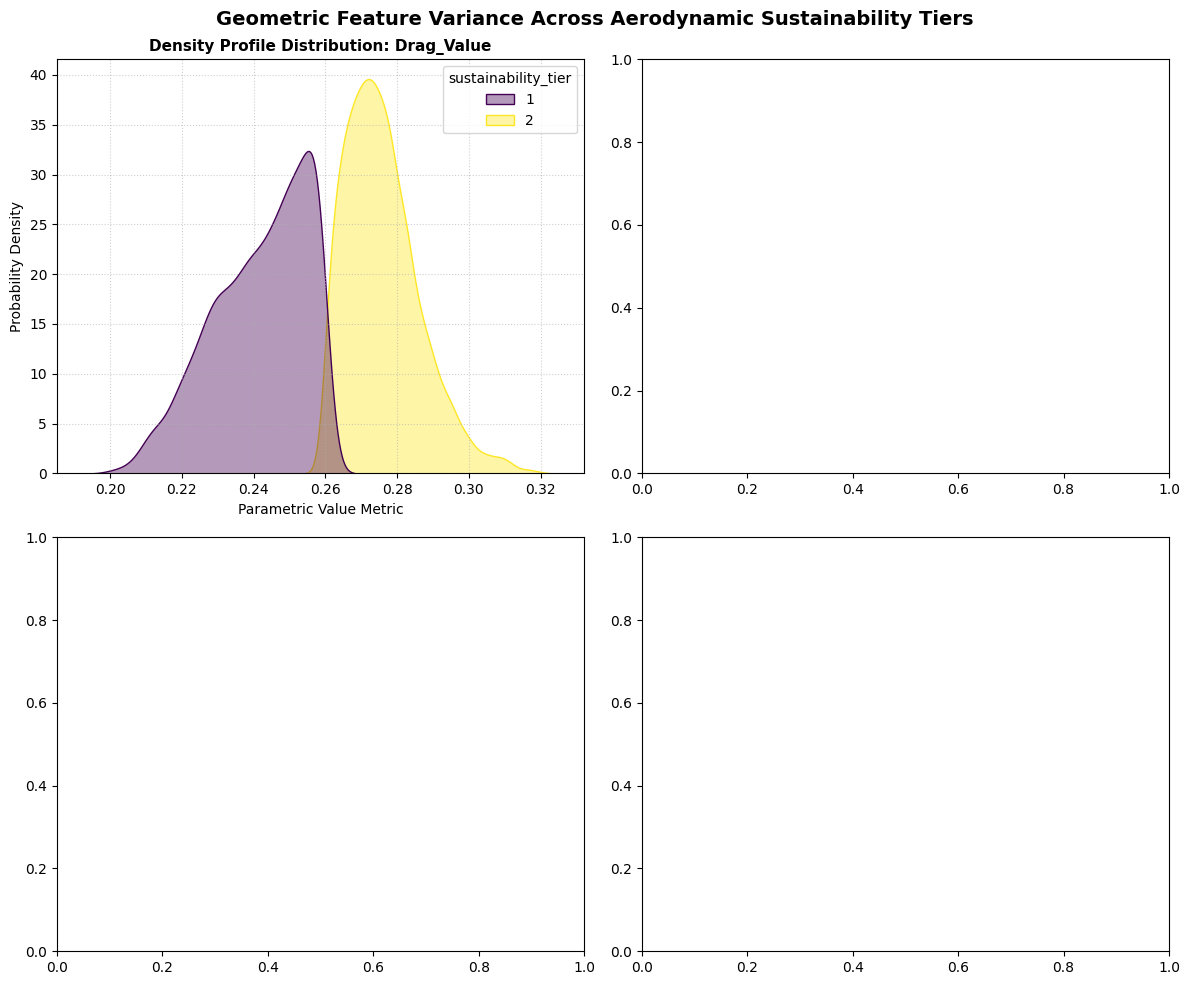

In [7]:
# Select 4 representative features from your top columns to evaluate variance across tiers
# Note: Replace these strings with 4 actual column names printed by your dataset if necessary
representative_features = feature_cols[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(representative_features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue='sustainability_tier',
        palette='viridis',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(f'Density Profile Distribution: {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Parametric Value Metric')
    axes[i].set_ylabel('Probability Density')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Geometric Feature Variance Across Aerodynamic Sustainability Tiers', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Save asset matching the Figure 4 template standard
plt.savefig('figure4_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()